In [1]:
import sys
sys.path.append("../src")

import time
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

from dataset import (
    gather_samples, stratified_split, compute_class_weights,
    RiceLeafDataset, CLASSES, FocalLoss
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
samples = gather_samples()
train_set, val_set, test_set = stratified_split(samples)
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

class_weights = compute_class_weights(train_set)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

Train: 1927 Val: 413 Test: 413
Class weights: [0.6523358 1.3973894 0.9331719 0.5652684 1.591247  1.4800308 1.6484175]


In [4]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_ds = RiceLeafDataset(train_set, split="train")
val_ds = RiceLeafDataset(val_set, split="val")
test_ds = RiceLeafDataset(test_set, split="test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Batches - train/val/test:", len(train_loader), len(val_loader), len(test_loader))

Batches - train/val/test: 61 13 13


In [4]:
NUM_CLASSES = len(CLASSES)

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(device)

print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True, bias=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=7, bias=True)
)


In [5]:
criterion = FocalLoss(alpha=class_weights_t, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

NUM_EPOCHS = 30
PATIENCE = 7

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [7]:
import sys
sys.path.append("../src")

import time, copy, gc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models

from dataset import (
    gather_samples, stratified_split, compute_class_weights,
    RiceLeafDataset, CLASSES, FocalLoss
)

gc.collect()
torch.cuda.empty_cache()

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [9]:
samples = gather_samples()
train_set, val_set, test_set = stratified_split(samples)
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

class_weights = compute_class_weights(train_set)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)


Train: 1927 Val: 413 Test: 413


In [10]:
BATCH_SIZE = 8
NUM_WORKERS = 2

train_ds = RiceLeafDataset(train_set, split="train")
val_ds = RiceLeafDataset(val_set, split="val")
test_ds = RiceLeafDataset(test_set, split="test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Batches - train/val/test:", len(train_loader), len(val_loader), len(test_loader))

Batches - train/val/test: 241 52 52


In [11]:
NUM_CLASSES = len(CLASSES)

model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(device)

In [12]:
criterion = FocalLoss(alpha=class_weights_t, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
scaler = torch.amp.GradScaler("cuda")

NUM_EPOCHS = 30
PATIENCE = 7

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [14]:
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"time={elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        torch.save(best_model_wts, "convnext_tiny_focal_best.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_wts)
print("Best val_loss:", best_val_loss)

Epoch 1/30 | train_loss=0.8657 train_acc=0.5086 | val_loss=0.5952 val_acc=0.5811 | time=73.9s
Epoch 2/30 | train_loss=0.4586 train_acc=0.7109 | val_loss=0.5105 val_acc=0.6949 | time=43.5s
Epoch 3/30 | train_loss=0.3640 train_acc=0.7587 | val_loss=0.5169 val_acc=0.7167 | time=45.4s
Epoch 4/30 | train_loss=0.3178 train_acc=0.7841 | val_loss=0.4903 val_acc=0.6901 | time=46.2s
Epoch 5/30 | train_loss=0.2402 train_acc=0.8044 | val_loss=0.5342 val_acc=0.7167 | time=46.6s
Epoch 6/30 | train_loss=0.2323 train_acc=0.8147 | val_loss=0.5364 val_acc=0.7070 | time=47.6s
Epoch 7/30 | train_loss=0.1816 train_acc=0.8490 | val_loss=0.4755 val_acc=0.7337 | time=45.8s
Epoch 8/30 | train_loss=0.1552 train_acc=0.8604 | val_loss=0.5253 val_acc=0.7119 | time=46.6s
Epoch 9/30 | train_loss=0.1338 train_acc=0.8760 | val_loss=0.6001 val_acc=0.7264 | time=46.5s
Epoch 10/30 | train_loss=0.1317 train_acc=0.8921 | val_loss=0.5771 val_acc=0.6659 | time=46.4s
Epoch 11/30 | train_loss=0.0869 train_acc=0.9159 | val_loss

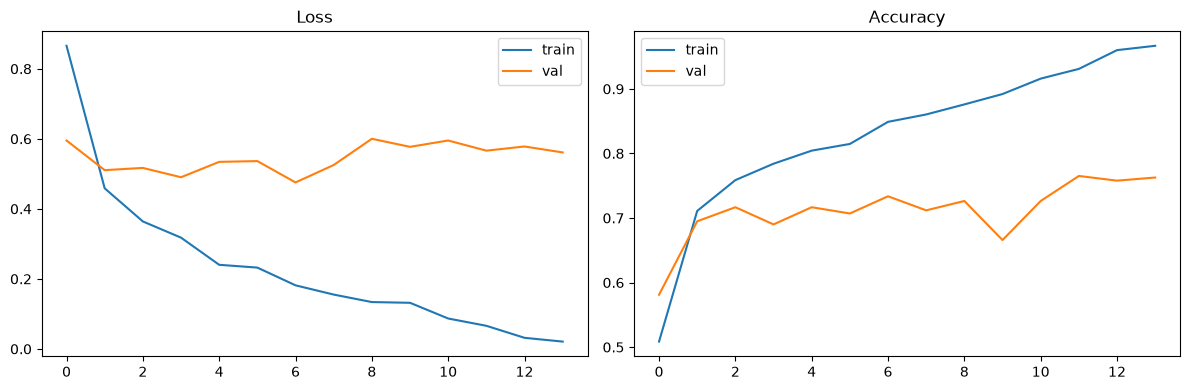

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print("Macro-F1:", f1_score(all_labels, all_preds, average="macro"))
print(classification_report(all_labels, all_preds, target_names=CLASSES))
print("Confusion matrix:\n", confusion_matrix(all_labels, all_preds))

Macro-F1: 0.7398222729910399
                 precision    recall  f1-score   support

        Healthy       0.90      0.79      0.84        90
         Insect       0.83      0.83      0.83        42
     Leaf Scald       0.93      0.41      0.57        63
     Rice Blast       0.87      0.88      0.87       105
Rice Leaffolder       0.68      0.86      0.76        37
   Rice Stripes       0.47      0.75      0.58        40
    Rice Tungro       0.64      0.83      0.72        36

       accuracy                           0.77       413
      macro avg       0.76      0.77      0.74       413
   weighted avg       0.80      0.77      0.76       413

Confusion matrix:
 [[71  5  0  7  0  1  6]
 [ 1 35  1  0  3  2  0]
 [ 0  1 26  1 10 23  2]
 [ 4  0  0 92  0  3  6]
 [ 0  1  0  2 32  2  0]
 [ 0  0  1  4  2 30  3]
 [ 3  0  0  0  0  3 30]]


In [17]:
import time as _time

num_params = sum(p.numel() for p in model.parameters())
print("Total params:", num_params)

model.eval()
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    for _ in range(5):
        model(dummy)
    torch.cuda.synchronize()
    start = _time.time()
    for _ in range(50):
        model(dummy)
    torch.cuda.synchronize()
    elapsed = _time.time() - start

print("Avg inference time (ms):", (elapsed / 50) * 1000)

Total params: 27825511
Avg inference time (ms): 5.232682228088379
